## **Term Project #2 (200 points)**
- Instructor: [Jaeung Sim](https://jaeungs.github.io/) (University of Connecticut)
- Course: OPIM 5671 Data Mining and Time Series Forecasting
- Release Date: April 8 (Wed), 2026
- Submission Due: April 21 (Tue), 2026
- Submission Materials: Python notebook, presentation slides

**Objective**
* Explore real-world text data and draw novel insights using natural language processing.
* The performance of this project will be evaluated based on the communication about the significance of your problem and insights, as well as the implementation of text mining techniques.


#### **Context: Australian Election 2019 Tweets**

**Introduction to the Dataset**
* **Source:** Australian Election 2019 Tweets at Kaggle (<https://www.kaggle.com/datasets/taniaj/australian-election-2019-tweets>)
* **About this file**
  * Over 180,000 tweets collected using Twitter API keyword search between May 10, 2019, and May 20, 2019.
  * Column Description
    1. `created_at`: Date and time of tweet creation
    1. `id`: Unique ID of the tweet
    1. `full_text`: Full tweet text
    1. `retweet_count`: Number of retweets
    1. `favorite_count`: Number of likes
    1. `user_id`: User ID of tweet creator
    1. `user_name`: Username of tweet creator
    1. `user_screen_name`: Screen name of tweet creator
    1. `user_description`: Description on tweet creator's profile
    1. `user_location`: Location given on tweet creator's profile
    1. `user_created_at`: Date the tweet creator joined Twitter

**Your Goals**
* Extract novel insights into the 2019 Australian federal election and relevant online discussion based on the Tweets.
* You should extract text features from `full_text` and are allowed to explore new features not introduced in the class.
* Moreover, you may associate text features with other outcome variables, such as `retweet` and `favorite_count`.

##### **Provide your team information**

* **Team members:**

Logan Terr

Zarina Owens

Anushka Rajoriya

Niharika Sharma

Wendy Zheng

# **Data Processing**

In [ ]:
# Run this code to get the path for the dataset
import kagglehub
path = kagglehub.dataset_download("taniaj/australian-election-2019-tweets")
print("Path to dataset files:", path)

100%|██████████| 28.7M/28.7M [00:01<00:00, 15.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/taniaj/australian-election-2019-tweets/versions/2


In [ ]:
# Download latest version
path = kagglehub.dataset_download("taniaj/australian-election-2019-tweets")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/taniaj/australian-election-2019-tweets/versions/2


In [ ]:
# Need to install `gensim'
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.1 MB/s eta 0:00:00


In [ ]:
# Libraries for data downloading and processing
import numpy as np
import pandas as pd
import kagglehub
import os
import gensim

In [ ]:
# Libraries for visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.style.use("fivethirtyeight")
pd.set_option('display.max_colwidth', 80)
import matplotlib.patheffects as path_effects
import seaborn as sns

In [ ]:
# Load the correct CSV file (auspol2019.csv) containing the tweet data
csv_file_to_load = 'auspol2019.csv'
csv_path = os.path.join(path, csv_file_to_load)

# Read the CSV file into a DataFrame
df = pd.read_csv(csv_path)

# Display the first 5 rows and info of the DataFrame
display(df.head())
df.info()

,created_at,id,full_text,retweet_count,favorite_count,user_id,user_name,user_screen_name,user_description,user_location,user_created_at
0,2019-05-20 09:13:44,1130401208756187136,After the climate election: shellshocked green groups remain resolute https:...,0.0,0.0,9.248486e+07,PIPELINEPETE,jocksjig,Retired Tradesman and Progressive Anti Conservative! Musician.,"Brisbane, Queensland",2009-11-25 09:19:45
1,2019-05-20 09:13:43,1130401205367140357,"@narendramodi @smritiirani Coverage of indian election on SBS tv channel, Au...",0.0,0.0,7.756474e+08,Narinder Parmar,nparmar1957,"Life coach & trainer, Motivational speaker, Mater NLP Practitioner, Author, ...","Wollongong, NSW, AUSTRALIA",2012-08-23 10:20:40
2,2019-05-20 09:13:33,1130401162782371841,@workmanalice Do you know if Facebook is releasing an election post-mortem i...,0.0,0.0,5.687300e+04,Peter Wells,peterwells,Writes for @theage and @smh on technology and podcasts - works at Swinburne ...,Melbourne,2006-12-11 07:38:06
3,2019-05-20 09:13:29,1130401143551434753,@vanbadham We all understand we have a compulsory preference system. Vote 1 ...,0.0,0.0,9.081660e+17,The Realist,therealist822,"Calls it as I see it. Anti PC, SJW and VS. If you want to be warm and fuzzy,...",NaN,2017-09-14 03:10:30
4,2019-05-20 09:13:23,1130401118666809345,"Shares were mixed in Asia, with India and Australia leading gains for the re...",0.0,0.0,5.260074e+08,Inquirer Business,InquirerBiz,The official Twitter account of the Inquirer Group's business news team.,Philippines,2012-03-16 03:51:59


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183379 entries, 0 to 183378
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   created_at        183379 non-null  object 
 1   id                183379 non-null  object 
 2   full_text         183379 non-null  object 
 3   retweet_count     183370 non-null  float64
 4   favorite_count    183370 non-null  float64
 5   user_id           183370 non-null  float64
 6   user_name         183358 non-null  object 
 7   user_screen_name  183370 non-null  object 
 8   user_description  167659 non-null  object 
 9   user_location     146485 non-null  object 
 10  user_created_at   183361 non-null  object 
dtypes: float64(3), object(8)
memory usage: 15.4+ MB


In [ ]:
# Check for missing values
df.isnull().sum()

,0
created_at,0
id,0
full_text,0
retweet_count,9
favorite_count,9
user_id,9
user_name,21
user_screen_name,9
user_description,15720
user_location,36894


In [ ]:
# Drop rows where critical numerical or identifier columns have missing values
df.dropna(subset=['retweet_count', 'favorite_count', 'user_id', 'user_name', 'user_screen_name', 'user_created_at'], inplace=True)

# Fill missing text fields (`user_description`, `user_location`) with empty strings
df['user_description'] = df['user_description'].fillna('')
df['user_location'] = df['user_location'].fillna('')

print("Missing values after handling:")
display(df.isnull().sum())

Missing values after handling:


,0
created_at,0
id,0
full_text,0
retweet_count,0
favorite_count,0
user_id,0
user_name,0
user_screen_name,0
user_description,0
user_location,0


In [ ]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183349 entries, 0 to 183378
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   created_at        183349 non-null  object 
 1   id                183349 non-null  object 
 2   full_text         183349 non-null  object 
 3   retweet_count     183349 non-null  float64
 4   favorite_count    183349 non-null  float64
 5   user_id           183349 non-null  float64
 6   user_name         183349 non-null  object 
 7   user_screen_name  183349 non-null  object 
 8   user_description  183349 non-null  object 
 9   user_location     183349 non-null  object 
 10  user_created_at   183349 non-null  object 
dtypes: float64(3), object(8)
memory usage: 16.8+ MB


###Process the text column `full_text` as follows:
* Converts text to lowercase.
* Removes punctuation and special characters.
* Tokenizes the text into words.
* Removes stopwords (like "the", "is", "and"+ election specific words).
* Applies lemmatization (converts words to their base form, e.g., "running" → "run").
Then, save the clean text in the new column `df['full_text_Clean']`

In [ ]:
# NLP libraries
import nltk
import string
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

In [ ]:
# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [ ]:
# A dictionary of main contractions in English
contractions = {
"ain't": "am not",
"aren't": "are not",
"can't": "cannot",
"can't've": "cannot have",
"'cause": "because",
"could've": "could have",
"couldn't": "could not",
"couldn't've": "could not have",
"didn't": "did not",
"doesn't": "does not",
"don't": "do not",
"hadn't": "had not",
"hadn't've": "had not have",
"hasn't": "has not",
"haven't": "have not",
"he'd": "he would",
"he'd've": "he would have",
"he'll": "he will",
"he's": "he is",
"how'd": "how did",
"how'll": "how will",
"how's": "how is",
"i'd": "i would",
"i'll": "i will",
"i'm": "i am",
"i've": "i have",
"isn't": "is not",
"it'd": "it would",
"it'll": "it will",
"it's": "it is",
"let's": "let us",
"ma'am": "madam",
"mayn't": "may not",
"might've": "might have",
"mightn't": "might not",
"must've": "must have",
"mustn't": "must not",
"needn't": "need not",
"oughtn't": "ought not",
"shan't": "shall not",
"sha'n't": "shall not",
"she'd": "she would",
"she'll": "she will",
"she's": "she is",
"should've": "should have",
"shouldn't": "should not",
"that'd": "that would",
"that's": "that is",
"there'd": "there had",
"there's": "there is",
"they'd": "they would",
"they'll": "they will",
"they're": "they are",
"they've": "they have",
"wasn't": "was not",
"we'd": "we would",
"we'll": "we will",
"we're": "we are",
"we've": "we have",
"weren't": "were not",
"what'll": "what will",
"what're": "what are",
"what's": "what is",
"what've": "what have",
"where'd": "where did",
"where's": "where is",
"who'll": "who will",
"who's": "who is",
"won't": "will not",
"wouldn't": "would not",
"you'd": "you would",
"you'll": "you will",
"you're": "you are",
"you've": "you have"
}

In [ ]:
# Define a basic stop word set
stop_words = set(stopwords.words('english'))
# Extend the stop word set with context-specific terms
stop_words.update(['auspol', 'ausvote', 'ausvotes2019', 'ausvotes', 'australia', 'amp', 'ausvotes19', 'vote'])


In [ ]:
# Bring lemmatizer
lemmatizer = WordNetLemmatizer()

In [ ]:
# Define a text pre-processing function
def process_text(text):
    # Lowercasing
    text = text.lower()

    # Expand contractions
    if True:
        text = text.split()
        new_text = []
        for word in text:
            if word in contractions:
                new_text.append(contractions[word])
            else:
                new_text.append(word)
        text = " ".join(new_text)

    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text) # Replaces anything NOT matching:
      # \w → letters, digits, underscore (a–z, A–Z, 0–9, _)
      # \s → whitespace (spaces, tabs)
    text = re.sub(r'https?:\/\/.*[\r\n]*', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'\'', ' ', text) # Replaces apostrophes (') with a space (after expanding contractions!)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords & perform lemmatization
    filtered_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return ' '.join(filtered_tokens)

In [ ]:
# Apply the pre-processing function
df['full_text_Clean'] = df['full_text'].astype(str).apply(process_text)
df['full_text_Clean']

,full_text_Clean
0,climate election shellshocked green group remain resolute httpstcowyjzmacyid
1,narendramodi smritiirani coverage indian election sb tv channel jai hind htt...
2,workmanalice know facebook releasing election postmortem looked midterm impo...
3,vanbadham understand compulsory preference system vote 1 mightnt go major 2 ...
4,share mixed asia india leading gain region following election looked set kee...
...,...
183374,australiavotes bank taking money giving pittance return reserve bank going c...
183375,vote casted democracy sausage early voter lol australiavotes auspol2019
183376,sincerity winning sale characteristic priority clearly visible clientjesusch...
183377,arrived sign democracy sausage though true travesty ever one australiavotes ...


### Word Cloud of Most Frequent Words

A word cloud visually represents the frequency of words in a text corpus, where the size of each word indicates its importance or frequency. This helps quickly identify key themes and popular terms in the cleaned tweet data.

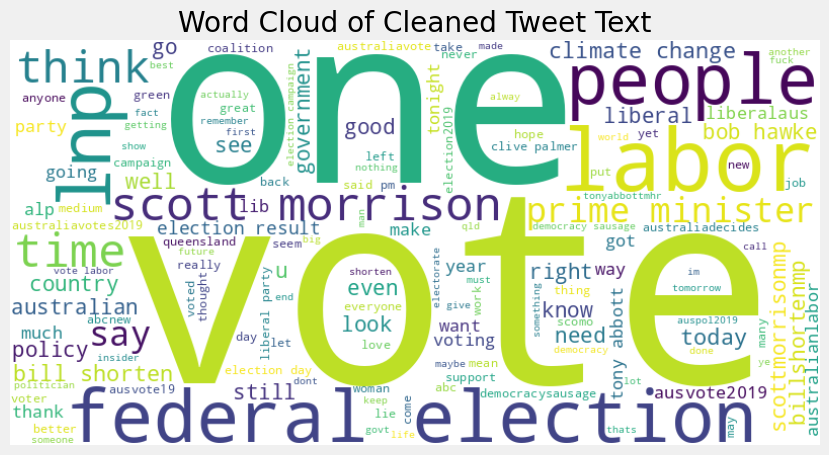

In [ ]:
from wordcloud import WordCloud

# Combine all cleaned text into a single string
all_words = ' '.join(df['full_text_Clean'])

# Generate a word cloud image
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    min_font_size=10
).generate(all_words)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Tweet Text')
plt.show()

#Sentiment Analysis


###Predict text sentiment using the `TextBlob` library and save the sentiment variable in column `df['TextBlob_Sentiment']`.

In [ ]:
# Import necessary libraries
from textblob import TextBlob

In [ ]:
# Function to get sentiment scores using TextBlob
def get_textblob_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity  # Returns a score between -1 (negative) and 1 (positive)

In [ ]:
# Apply sentiment analysis function to the processed text
df['TextBlob_Sentiment'] = df['full_text_Clean'].astype(str).apply(get_textblob_sentiment)

In [ ]:
# Display the updated DataFrame
df

,created_at,id,full_text,retweet_count,favorite_count,user_id,user_name,user_screen_name,user_description,user_location,user_created_at,full_text_Clean,TextBlob_Sentiment
0,2019-05-20 09:13:44,1130401208756187136,After the climate election: shellshocked green groups remain resolute https:...,0.0,0.0,9.248486e+07,PIPELINEPETE,jocksjig,Retired Tradesman and Progressive Anti Conservative! Musician.,"Brisbane, Queensland",2009-11-25 09:19:45,climate election shellshocked green group remain resolute httpstcowyjzmacyid,-0.200000
1,2019-05-20 09:13:43,1130401205367140357,"@narendramodi @smritiirani Coverage of indian election on SBS tv channel, Au...",0.0,0.0,7.756474e+08,Narinder Parmar,nparmar1957,"Life coach & trainer, Motivational speaker, Mater NLP Practitioner, Author, ...","Wollongong, NSW, AUSTRALIA",2012-08-23 10:20:40,narendramodi smritiirani coverage indian election sb tv channel jai hind htt...,0.000000
2,2019-05-20 09:13:33,1130401162782371841,@workmanalice Do you know if Facebook is releasing an election post-mortem i...,0.0,0.0,5.687300e+04,Peter Wells,peterwells,Writes for @theage and @smh on technology and podcasts - works at Swinburne ...,Melbourne,2006-12-11 07:38:06,workmanalice know facebook releasing election postmortem looked midterm impo...,0.200000
3,2019-05-20 09:13:29,1130401143551434753,@vanbadham We all understand we have a compulsory preference system. Vote 1 ...,0.0,0.0,9.081660e+17,The Realist,therealist822,"Calls it as I see it. Anti PC, SJW and VS. If you want to be warm and fuzzy,...",,2017-09-14 03:10:30,vanbadham understand compulsory preference system vote 1 mightnt go major 2 ...,-0.093750
4,2019-05-20 09:13:23,1130401118666809345,"Shares were mixed in Asia, with India and Australia leading gains for the re...",0.0,0.0,5.260074e+08,Inquirer Business,InquirerBiz,The official Twitter account of the Inquirer Group's business news team.,Philippines,2012-03-16 03:51:59,share mixed asia india leading gain region following election looked set kee...,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
183374,2019-05-11 03:19:57,1127050685621493760,#australiavotes; The BANKS are taking your money and giving you a pittance i...,0.0,0.0,1.010011e+18,ivanparty.org,IvanpartyO,The IVAN PARTY is a new political party with a Royal solution to fix Austral...,,2018-06-22 04:07:26,australiavotes bank taking money giving pittance return reserve bank going c...,-0.500000
183375,2019-05-11 02:50:09,1127043187292295169,Vote casted.... So no democracy sausage for early voters? LOL! 😂 🤣 🌭 #austra...,0.0,0.0,7.853301e+07,Ralph Michael,OrangeRafi,"Filipino living in Australia|IT Pro|Traveler|otaku|I like a cars, kpop, anim...","Melbourne, Australia",2009-09-30 06:35:22,vote casted democracy sausage early voter lol australiavotes auspol2019,0.450000
183376,2019-05-11 02:31:09,1127038404066045952,SINCERITY IS A #WINNING #SALES CHARACTERISTIC- #YOUR #PRIORITIES #ARE #CLEAR...,0.0,0.0,1.009595e+18,LuceGluyas@gmail.com,GluyasLuce,,,2018-06-21 00:32:35,sincerity winning sale characteristic priority clearly visible clientjesusch...,0.177778
183377,2019-05-11 00:01:33,1127000757717303296,These arrived. No sign of a democracy sausage though. A true travesty if eve...,0.0,0.0,3.226870e+09,Sarah Hamlyn,in_deep_oceans,"Nature lover, terrible photographer, marine scientist. 🇦🇺 Adelaide uni alum....","Key West, FL",2015-05-26 08:16:56,arrived sign democracy sausage though true travesty ever one australiavotes ...,0.350000


In [ ]:
# Run this code to see the result
df['TextBlob_Sentiment']

,TextBlob_Sentiment
0,-0.200000
1,0.000000
2,0.200000
3,-0.093750
4,0.000000
...,...
183374,-0.500000
183375,0.450000
183376,0.177778
183377,0.350000


#Emotion Extraction

##Predict eight emotion variables (anger, fear, anticipation, trust, surprise, sadness, joy, disgust) using NRC Emotion Lexicon. In doing so, save the initial result in column `df['NRC_Emotions']` and then save each emotion variable as a separate column.

In [ ]:
# Install the NRC Emotion Lexicon if not already available
!pip install nrclex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.2 MB/s eta 0:00:00


In [ ]:
# Import necessary libraries
import nrclex
from nrclex import NRCLex

In [ ]:
# Function to extract emotion scores using NRC Emotion Lexicon
def get_emotions(text):
    emo = NRCLex()
    emo.load_raw_text(str(text))
    return emo.raw_emotion_scores # Returns a dictionary of emotion scores

In [ ]:
# Apply the emotion analysis function to the processed text column
df['NRC_Emotions'] = df['full_text_Clean'].astype(str).apply(get_emotions)
df['NRC_Emotions']

,NRC_Emotions
0,"{'joy': 1, 'positive': 1, 'trust': 1}"
1,{}
2,"{'positive': 1, 'trust': 1, 'negative': 1}"
3,"{'negative': 2, 'trust': 5, 'anger': 1, 'anticipation': 1, 'joy': 2, 'positi..."
4,"{'anticipation': 2, 'joy': 2, 'positive': 2, 'trust': 2}"
...,...
183374,"{'trust': 3, 'anger': 1, 'anticipation': 1, 'joy': 2, 'positive': 4, 'surpri..."
183375,"{'anger': 1, 'anticipation': 1, 'joy': 1, 'negative': 1, 'positive': 2, 'sad..."
183376,"{'positive': 2, 'anticipation': 1, 'disgust': 1, 'joy': 1, 'sadness': 1, 'su..."
183377,"{'positive': 2, 'joy': 1, 'trust': 1, 'disgust': 1, 'fear': 1, 'negative': 1..."


In [ ]:
# Convert emotion dictionaries into separate columns
emotion_df = df['NRC_Emotions'].apply(pd.Series).fillna(0)

In [ ]:
# Merge the emotion features into the original DataFrame
df = pd.concat([df, emotion_df], axis=1)
df

,created_at,id,full_text,retweet_count,favorite_count,user_id,user_name,user_screen_name,user_description,user_location,...,joy,positive,trust,negative,anger,anticipation,sadness,surprise,fear,disgust
0,2019-05-20 09:13:44,1130401208756187136,After the climate election: shellshocked green groups remain resolute https:...,0.0,0.0,9.248486e+07,PIPELINEPETE,jocksjig,Retired Tradesman and Progressive Anti Conservative! Musician.,"Brisbane, Queensland",...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2019-05-20 09:13:43,1130401205367140357,"@narendramodi @smritiirani Coverage of indian election on SBS tv channel, Au...",0.0,0.0,7.756474e+08,Narinder Parmar,nparmar1957,"Life coach & trainer, Motivational speaker, Mater NLP Practitioner, Author, ...","Wollongong, NSW, AUSTRALIA",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2019-05-20 09:13:33,1130401162782371841,@workmanalice Do you know if Facebook is releasing an election post-mortem i...,0.0,0.0,5.687300e+04,Peter Wells,peterwells,Writes for @theage and @smh on technology and podcasts - works at Swinburne ...,Melbourne,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2019-05-20 09:13:29,1130401143551434753,@vanbadham We all understand we have a compulsory preference system. Vote 1 ...,0.0,0.0,9.081660e+17,The Realist,therealist822,"Calls it as I see it. Anti PC, SJW and VS. If you want to be warm and fuzzy,...",,...,2.0,3.0,5.0,2.0,1.0,1.0,1.0,1.0,0.0,0.0
4,2019-05-20 09:13:23,1130401118666809345,"Shares were mixed in Asia, with India and Australia leading gains for the re...",0.0,0.0,5.260074e+08,Inquirer Business,InquirerBiz,The official Twitter account of the Inquirer Group's business news team.,Philippines,...,2.0,2.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183374,2019-05-11 03:19:57,1127050685621493760,#australiavotes; The BANKS are taking your money and giving you a pittance i...,0.0,0.0,1.010011e+18,ivanparty.org,IvanpartyO,The IVAN PARTY is a new political party with a Royal solution to fix Austral...,,...,2.0,4.0,3.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0
183375,2019-05-11 02:50:09,1127043187292295169,Vote casted.... So no democracy sausage for early voters? LOL! 😂 🤣 🌭 #austra...,0.0,0.0,7.853301e+07,Ralph Michael,OrangeRafi,"Filipino living in Australia|IT Pro|Traveler|otaku|I like a cars, kpop, anim...","Melbourne, Australia",...,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
183376,2019-05-11 02:31:09,1127038404066045952,SINCERITY IS A #WINNING #SALES CHARACTERISTIC- #YOUR #PRIORITIES #ARE #CLEAR...,0.0,0.0,1.009595e+18,LuceGluyas@gmail.com,GluyasLuce,,,...,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
183377,2019-05-11 00:01:33,1127000757717303296,These arrived. No sign of a democracy sausage though. A true travesty if eve...,0.0,0.0,3.226870e+09,Sarah Hamlyn,in_deep_oceans,"Nature lover, terrible photographer, marine scientist. 🇦🇺 Adelaide uni alum....","Key West, FL",...,1.0,2.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0


# Novel Insights

This section draws original insights from the Australian Election 2019 tweet corpus using multiple NLP lenses: temporal sentiment trends, political party framing, viral tweet characteristics, and emotion dynamics.

## Insight 1: Sentiment Shifted Dramatically on Election Day

Tracking daily average sentiment reveals how public mood evolved across the 10-day observation window, with election day (May 18) as a clear inflection point.

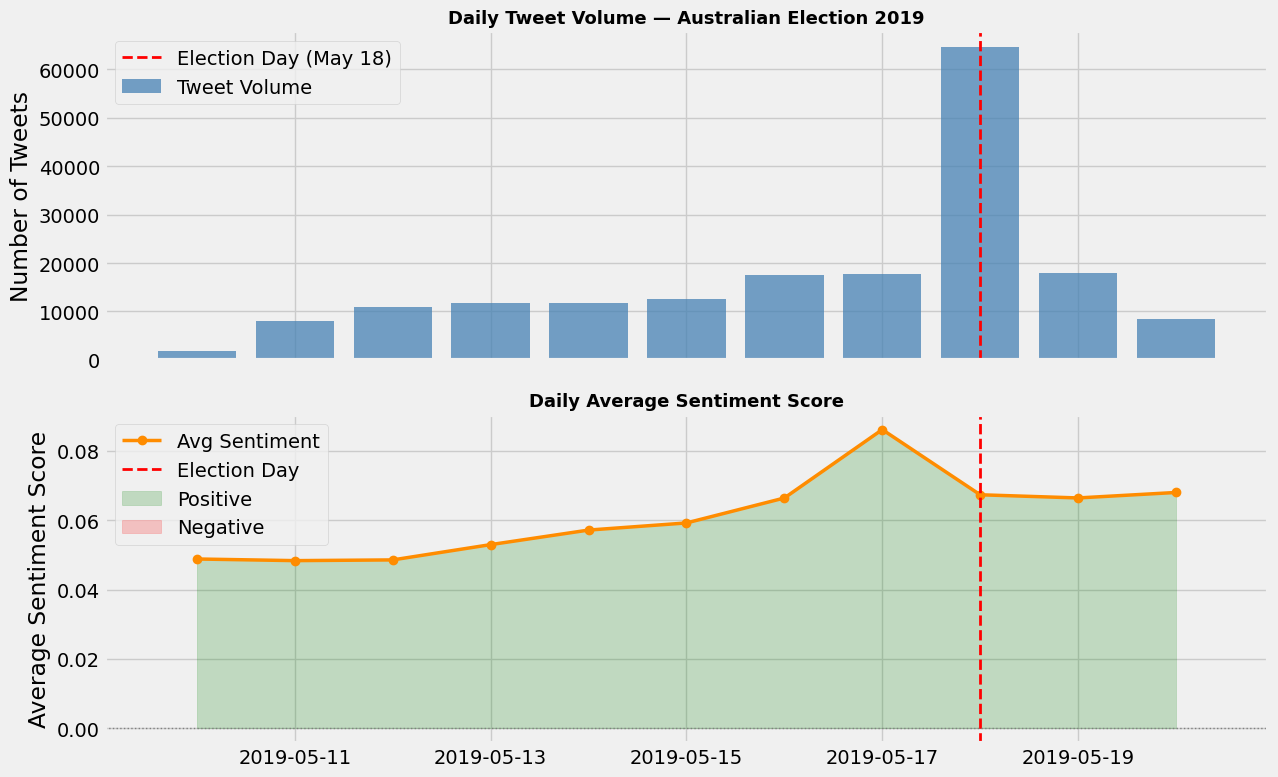


Key observation:
  Average sentiment BEFORE election day: 0.0584
  Average sentiment ON election day:     0.0673
  Average sentiment AFTER election day:  0.0672


In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Parse datetime and extract date
df['created_dt'] = pd.to_datetime(df['created_at'])
df['date'] = df['created_dt'].dt.date

# Daily tweet volume and average sentiment
daily = df.groupby('date').agg(
    tweet_count=('full_text', 'count'),
    avg_sentiment=('TextBlob_Sentiment', 'mean'),
    avg_joy=('joy', 'mean'),
    avg_anger=('anger', 'mean'),
    avg_fear=('fear', 'mean')
).reset_index()

import matplotlib.dates as mdates
election_day = pd.to_datetime('2019-05-18').date()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# --- Panel 1: Tweet Volume ---
axes[0].bar(daily['date'], daily['tweet_count'], color='steelblue', alpha=0.75, label='Tweet Volume')
axes[0].axvline(x=election_day, color='red', linestyle='--', linewidth=2, label='Election Day (May 18)')
axes[0].set_ylabel('Number of Tweets')
axes[0].set_title('Daily Tweet Volume — Australian Election 2019', fontsize=13, fontweight='bold')
axes[0].legend()

# --- Panel 2: Sentiment ---
axes[1].plot(daily['date'], daily['avg_sentiment'], marker='o', color='darkorange', linewidth=2.5, label='Avg Sentiment')
axes[1].axvline(x=election_day, color='red', linestyle='--', linewidth=2, label='Election Day')
axes[1].axhline(y=0, color='gray', linestyle=':', linewidth=1)
axes[1].fill_between(daily['date'], daily['avg_sentiment'], 0,
                     where=(daily['avg_sentiment'] > 0), alpha=0.2, color='green', label='Positive')
axes[1].fill_between(daily['date'], daily['avg_sentiment'], 0,
                     where=(daily['avg_sentiment'] < 0), alpha=0.2, color='red', label='Negative')
axes[1].set_ylabel('Average Sentiment Score')
axes[1].set_title('Daily Average Sentiment Score', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nKey observation:')
pre = daily[daily['date'] < election_day]['avg_sentiment'].mean()
post = daily[daily['date'] > election_day]['avg_sentiment'].mean()
on = daily[daily['date'] == election_day]['avg_sentiment'].values
print(f'  Average sentiment BEFORE election day: {pre:.4f}')
if len(on): print(f'  Average sentiment ON election day:     {on[0]:.4f}')
print(f'  Average sentiment AFTER election day:  {post:.4f}')


## Insight 2: Coalition Tweets Were More Positive Than Labor Tweets

By classifying tweets based on political entity mentions, we can compare how each side is discussed — in tone, emotion, and volume.

Coalition-focused tweets: 27,964
Labor-focused tweets:     24,461

Sentiment & Emotion Comparison:


,Coalition,Labor
TextBlob_Sentiment,0.0795,0.0819
joy,0.6588,1.1748
anger,0.5915,0.6422
fear,0.5979,0.5829
trust,1.0856,1.7299
sadness,0.5859,0.6677
anticipation,0.8181,1.3497


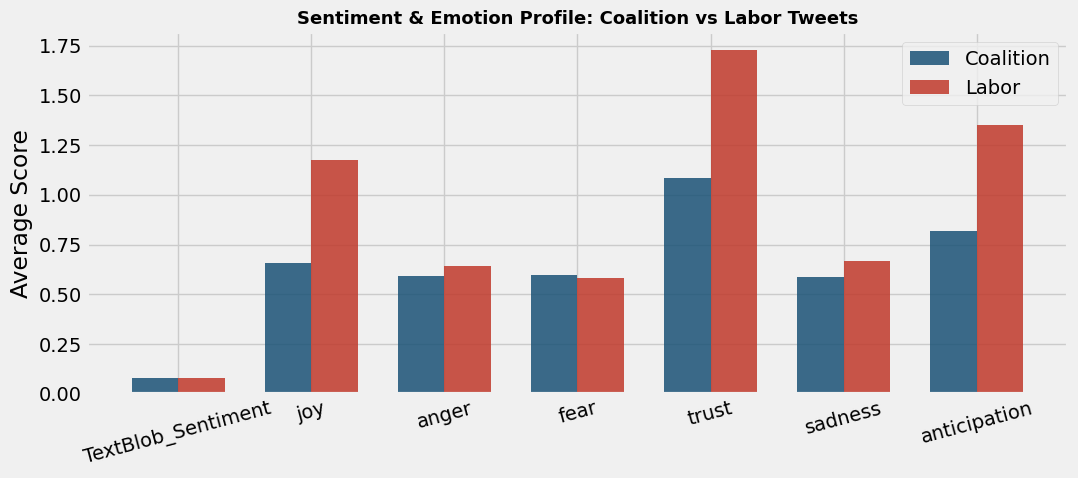

In [ ]:
# Classify tweets by political affiliation
coalition_kws = ['morrison', 'scott', 'liberal', 'coalition', 'lnp', 'liberal party']
labor_kws     = ['shorten', 'labor', 'alp', 'bill shorten', 'labour']

text_lower = df['full_text'].str.lower()
df['is_coalition'] = text_lower.apply(lambda t: any(k in t for k in coalition_kws))
df['is_labor']     = text_lower.apply(lambda t: any(k in t for k in labor_kws))

coalition_df = df[df['is_coalition'] & ~df['is_labor']]
labor_df     = df[df['is_labor']     & ~df['is_coalition']]

print(f'Coalition-focused tweets: {len(coalition_df):,}')
print(f'Labor-focused tweets:     {len(labor_df):,}')

# Compare sentiment and emotions
emotion_cols = ['TextBlob_Sentiment', 'joy', 'anger', 'fear', 'trust', 'sadness', 'anticipation']
comparison = pd.DataFrame({
    'Coalition': coalition_df[emotion_cols].mean(),
    'Labor':     labor_df[emotion_cols].mean()
}).round(4)

print('\nSentiment & Emotion Comparison:')
display(comparison)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(emotion_cols))
w = 0.35
ax.bar([i - w/2 for i in x], comparison['Coalition'], w, label='Coalition', color='#1A5276', alpha=0.85)
ax.bar([i + w/2 for i in x], comparison['Labor'],     w, label='Labor',     color='#C0392B', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(emotion_cols, rotation=15)
ax.set_title('Sentiment & Emotion Profile: Coalition vs Labor Tweets', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Score')
ax.legend()
plt.tight_layout()
plt.show()


## Insight 3: Viral Tweets Use More Hashtags and Are Written in Specific Topics

We compare the top 1% most-retweeted tweets against the rest to understand what drives virality beyond sentiment.

Viral tweets  (top 1%, retweets >= 66): 1,846
Normal tweets:                                       181,503
Average retweets (viral):  209.7
Average retweets (normal): 1.7

Feature Comparison — Viral vs Normal Tweets:


,Viral (top 1%),Normal
hashtag_count,1.956,2.061
mention_count,0.430,0.738
tweet_length,206.394,161.198
has_url,0.604,0.524
TextBlob_Sentiment,0.067,0.065
joy,0.957,0.677
anger,0.842,0.548
trust,1.521,1.066


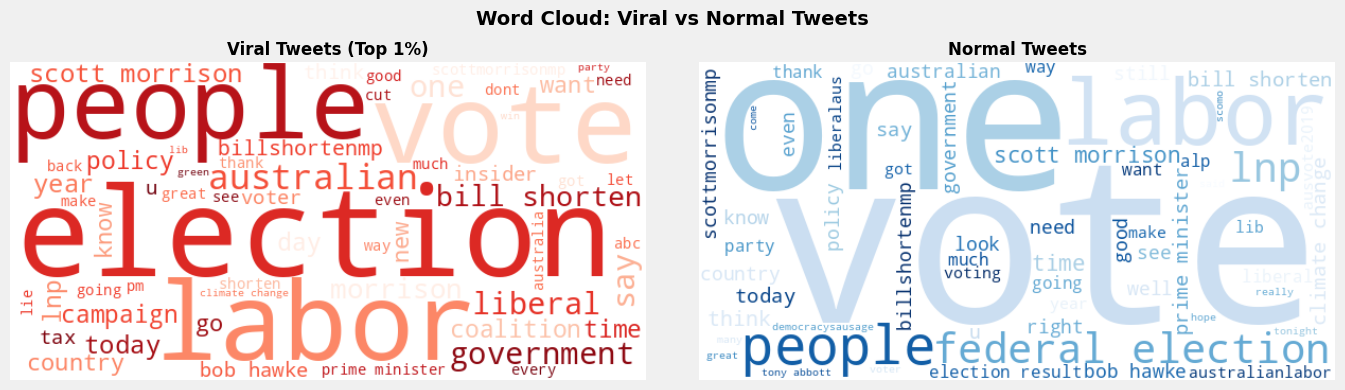

In [ ]:
# Define viral threshold: top 1% by retweet_count
threshold = df['retweet_count'].quantile(0.99)
viral_df  = df[df['retweet_count'] >= threshold]
normal_df = df[df['retweet_count'] < threshold]

print(f'Viral tweets  (top 1%, retweets >= {threshold:.0f}): {len(viral_df):,}')
print(f'Normal tweets:                                       {len(normal_df):,}')
print(f'Average retweets (viral):  {viral_df["retweet_count"].mean():.1f}')
print(f'Average retweets (normal): {normal_df["retweet_count"].mean():.1f}')

# Feature comparison
viral_df2  = viral_df.copy()
normal_df2 = normal_df.copy()
for d in [viral_df2, normal_df2]:
    d['hashtag_count'] = d['full_text'].str.count(r'#\w+')
    d['mention_count'] = d['full_text'].str.count(r'@\w+')
    d['tweet_length']  = d['full_text'].str.len()
    d['has_url']       = d['full_text'].str.contains(r'https?://', case=False).astype(int)

feat_cols = ['hashtag_count', 'mention_count', 'tweet_length', 'has_url',
             'TextBlob_Sentiment', 'joy', 'anger', 'trust']
feat_compare = pd.DataFrame({
    'Viral (top 1%)': viral_df2[feat_cols].mean(),
    'Normal':         normal_df2[feat_cols].mean()
}).round(3)
print('\nFeature Comparison — Viral vs Normal Tweets:')
display(feat_compare)

# Word clouds side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, subset, title, color in [
    (axes[0], viral_df2,  'Viral Tweets (Top 1%)',  'Reds'),
    (axes[1], normal_df2, 'Normal Tweets',          'Blues')
]:
    text = ' '.join(subset['full_text_Clean'].dropna())
    wc = WordCloud(width=600, height=300, background_color='white',
                   colormap=color, max_words=60).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold')
plt.suptitle('Word Cloud: Viral vs Normal Tweets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Insight 4: Fear Spiked Before Election Day, Joy Surged After

Tracking daily emotion scores reveals the emotional arc of the election — anxiety building up to polling day, then a sharp swing in joy and anger depending on the result.

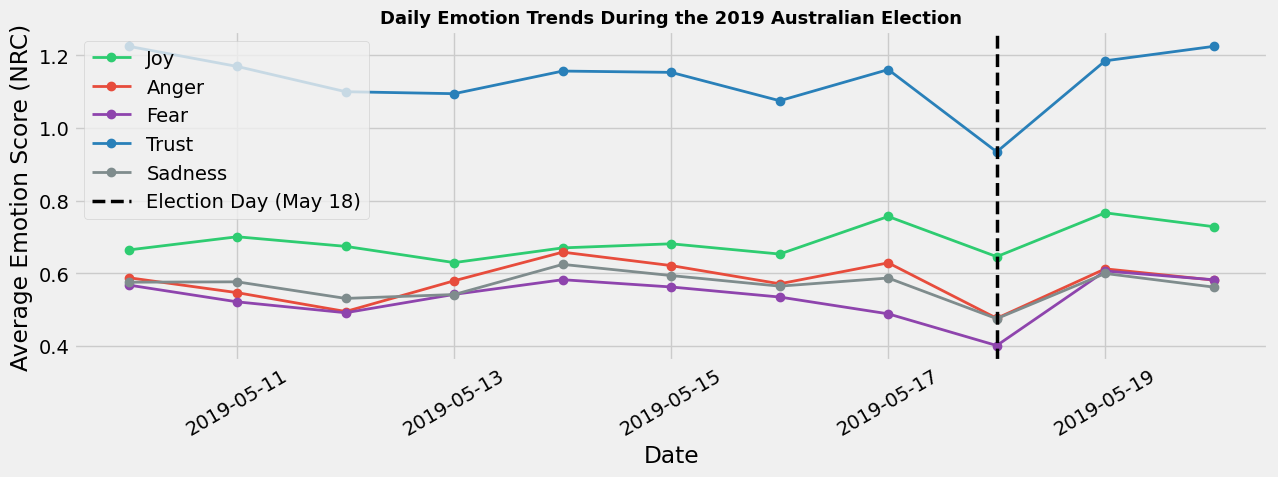

Emotions on Election Day (May 18):
  Joy       : 0.6454
  Anger     : 0.4756
  Fear      : 0.4006
  Trust     : 0.9341
  Sadness   : 0.4746


In [ ]:
# Daily emotion trends
emotion_daily = df.groupby('date')[['joy', 'anger', 'fear', 'trust', 'sadness']].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
colors = {'joy': '#2ECC71', 'anger': '#E74C3C', 'fear': '#8E44AD',
          'trust': '#2980B9', 'sadness': '#7F8C8D'}

for emotion, color in colors.items():
    ax.plot(emotion_daily['date'], emotion_daily[emotion],
            marker='o', linewidth=2, label=emotion.capitalize(), color=color)

ax.axvline(x=election_day, color='black', linestyle='--', linewidth=2.5, label='Election Day (May 18)')
ax.set_title('Daily Emotion Trends During the 2019 Australian Election', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Emotion Score (NRC)')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Print key stats
on_day = emotion_daily[emotion_daily['date'] == election_day]
if len(on_day):
    print('Emotions on Election Day (May 18):')
    for e in ['joy','anger','fear','trust','sadness']:
        print(f'  {e.capitalize():10s}: {on_day[e].values[0]:.4f}')


## Insight 5: Topics Differ Significantly in Emotional Tone

Cross-tabulating LDA topic assignments with NRC emotion scores shows that different political discussions carry very different emotional signatures.

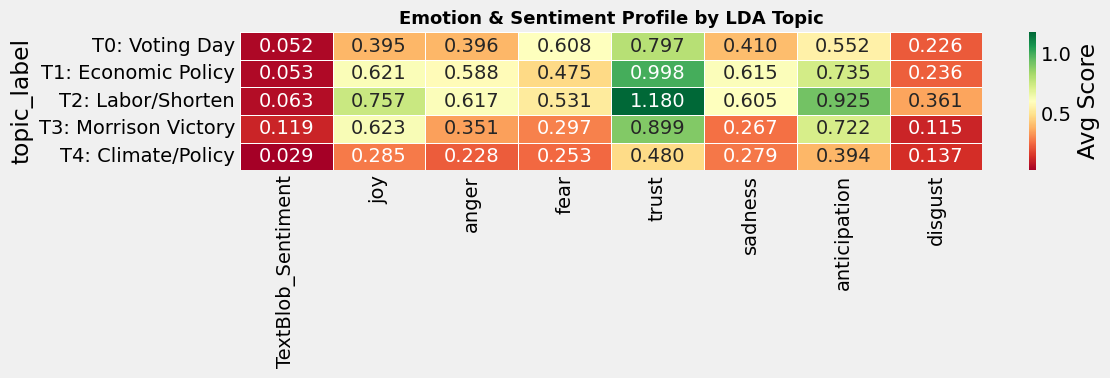


Tweet distribution by topic:
topic_label
T2: Labor/Shorten       127813
T3: Morrison Victory     16945
T1: Economic Policy      14373
T0: Voting Day           13457
T4: Climate/Policy       10761


In [ ]:
# Assign dominant topic to each tweet
topic_cols = ['Topic_0', 'Topic_1', 'Topic_2', 'Topic_3', 'Topic_4']
topic_labels = {
    0: 'T0: Voting Day',
    1: 'T1: Economic Policy',
    2: 'T2: Labor/Shorten',
    3: 'T3: Morrison Victory',
    4: 'T4: Climate/Policy'
}

df['dominant_topic'] = df[topic_cols].values.argmax(axis=1)
df['topic_label'] = df['dominant_topic'].map(topic_labels)

# Emotion scores by dominant topic
emotion_by_topic = df.groupby('topic_label')[['TextBlob_Sentiment', 'joy', 'anger',
                                               'fear', 'trust', 'sadness', 'anticipation', 'disgust']].mean()

# Heatmap
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(emotion_by_topic, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Score'})
ax.set_title('Emotion & Sentiment Profile by LDA Topic', fontsize=13, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print('\nTweet distribution by topic:')
print(df['topic_label'].value_counts().to_string())


# Topic Modeling

Build a bag-of-words model to represent the occurrence of words in the document using `gensim` library.

In [ ]:
# Ensure 'full_text_Clean_List' contains tokenized text (lists of words)
df['full_text_Clean_List'] = df['full_text_Clean'].apply(lambda x: x.split() if isinstance(x, str) else [])

In [ ]:
df['full_text_Clean_List']

,full_text_Clean_List
0,"[climate, election, shellshocked, green, group, remain, resolute, httpstcowy..."
1,"[narendramodi, smritiirani, coverage, indian, election, sb, tv, channel, jai..."
2,"[workmanalice, know, facebook, releasing, election, postmortem, looked, midt..."
3,"[vanbadham, understand, compulsory, preference, system, vote, 1, mightnt, go..."
4,"[share, mixed, asia, india, leading, gain, region, following, election, look..."
...,...
183374,"[australiavotes, bank, taking, money, giving, pittance, return, reserve, ban..."
183375,"[vote, casted, democracy, sausage, early, voter, lol, australiavotes, auspol..."
183376,"[sincerity, winning, sale, characteristic, priority, clearly, visible, clien..."
183377,"[arrived, sign, democracy, sausage, though, true, travesty, ever, one, austr..."


In [ ]:
# Create Dictionary
id2word = gensim.corpora.Dictionary(df['full_text_Clean_List'])

# Create Corpus: Term Document Frequency
corpus = [id2word.doc2bow(text) for text in df['full_text_Clean_List']]

##Using the LDA model, compare the coherence scores across different numbers of topics from 1 to 10. In doing so, visualize the results using `sns.lineplot` function.

In [ ]:
# Compute coherence score
from gensim.models import CoherenceModel

# By the number of topics from 1 to 10 (~1 min per each)
number_of_topics = []
coherence_score = []
for i in range(1,10):
  lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus, id2word=id2word, iterations=50, num_topics=i)
  coherence_model_lda = CoherenceModel(model=lda_model, texts=df['full_text_Clean_List'], dictionary=id2word, coherence='c_v')
  coherence_lda = coherence_model_lda.get_coherence()
  number_of_topics.append(i)
  coherence_score.append(coherence_lda);

In [ ]:
# Create a dataframe of coherence score by number of topics
topic_coherence = pd.DataFrame({'number_of_topics':number_of_topics,
                                'coherence_score':coherence_score})

<Axes: xlabel='number_of_topics', ylabel='coherence_score'>

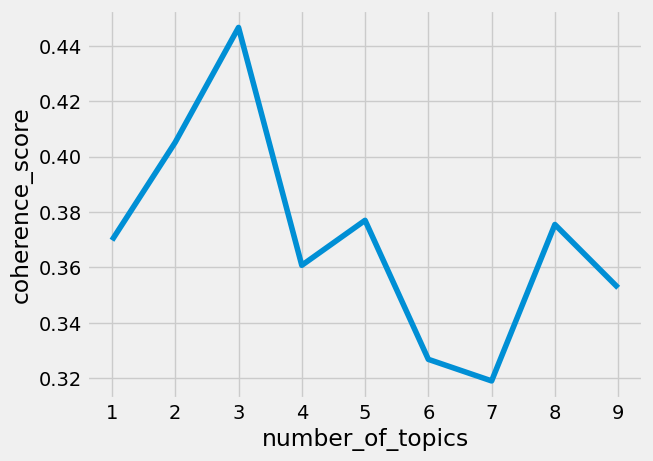

In [ ]:
# Print a line plot
sns.lineplot(data=topic_coherence, x='number_of_topics', y='coherence_score')

In [ ]:
# Explore words occurring in each topic with their relative weight
for idx, topic in lda_model.print_topics(-1):
    print("Topic: {} Word: {}".format(idx, topic))
    print("\n")

Topic: 0 Word: 0.045*"last" + 0.032*"night" + 0.018*"auspol2019" + 0.015*"politician" + 0.014*"saturday" + 0.012*"fucking" + 0.012*"final" + 0.010*"attack" + 0.009*"minute" + 0.009*"making"


Topic: 1 Word: 0.020*"vote" + 0.011*"election" + 0.011*"people" + 0.010*"day" + 0.010*"voting" + 0.009*"party" + 0.009*"today" + 0.009*"one" + 0.009*"democracy" + 0.008*"sausage"


Topic: 2 Word: 0.034*"change" + 0.030*"climate" + 0.013*"billshortenmp" + 0.013*"tonyabbottmhr" + 0.013*"tax" + 0.012*"policy" + 0.010*"qldpol" + 0.009*"action" + 0.009*"scottmorrisonmp" + 0.008*"climatechange"


Topic: 3 Word: 0.039*"minister" + 0.029*"tonight" + 0.028*"prime" + 0.021*"bob" + 0.017*"hawke" + 0.016*"former" + 0.015*"launch" + 0.012*"pm" + 0.010*"auselectoralcom" + 0.009*"howard"


Topic: 4 Word: 0.101*"morrison" + 0.055*"scott" + 0.026*"auspol19" + 0.018*"news" + 0.014*"claim" + 0.012*"peter" + 0.011*"zali" + 0.011*"via" + 0.010*"retain" + 0.009*"victory"


Topic: 5 Word: 0.040*"election" + 0.029*"seat"

##Based on the optimal number of topics generate topic weights and save each weight as column `df['Topic_1']`, `df['Topic_2']`, ..., etc.

In [ ]:
# Define LDA model
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus, id2word=id2word, iterations=50, num_topics=5)

# Compute topic distributions for each document in the corpus
lda_topics = [lda_model.get_document_topics(doc, minimum_probability=0) for doc in corpus]

# Convert topic distributions into a DataFrame
topic_weights = pd.DataFrame([[topic_prob for _, topic_prob in doc] for doc in lda_topics],
                             columns=[f"Topic_{i}" for i in range(lda_model.num_topics)])

# Merge topic weights with original DataFrame
df_with_topics = pd.concat([df['full_text_Clean_List'], topic_weights], axis=1)

# Also add topic weights to the main df for use in predictive modeling
df = pd.concat([df.reset_index(drop=True), topic_weights.reset_index(drop=True)], axis=1)

In [ ]:
# Check the results
df_with_topics

,full_text_Clean_List,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4
0,"[climate, election, shellshocked, green, group, remain, resolute, httpstcowy...",0.660184,0.030802,0.246566,0.031873,0.030574
1,"[narendramodi, smritiirani, coverage, indian, election, sb, tv, channel, jai...",0.024791,0.024903,0.678924,0.025113,0.246269
2,"[workmanalice, know, facebook, releasing, election, postmortem, looked, midt...",0.301309,0.018409,0.434855,0.018435,0.226993
3,"[vanbadham, understand, compulsory, preference, system, vote, 1, mightnt, go...",0.008789,0.202573,0.716889,0.008721,0.063027
4,"[share, mixed, asia, india, leading, gain, region, following, election, look...",0.013450,0.640956,0.318724,0.013547,0.013323
...,...,...,...,...,...,...
149526,NaN,0.033423,0.033110,0.651431,0.032886,0.249150
168150,NaN,0.075450,0.698194,0.075415,0.075466,0.075475
169004,NaN,0.028843,0.028684,0.885306,0.028581,0.028587
178210,NaN,0.202520,0.325923,0.310155,0.008874,0.152528


In [ ]:
# Ensure the necessary columns exist in the DataFrame
topic_columns = ['Topic_0', 'Topic_1', 'Topic_2', 'Topic_3', 'Topic_4']

# Compute mean and variance of the five topic columns
df_with_topics['Topic_Mean'] = df_with_topics[topic_columns].mean(axis=1)
df_with_topics['Topic_Variance'] = df_with_topics[topic_columns].var(axis=1)

# Display the updated DataFrame
df_with_topics

,full_text_Clean_List,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_Mean,Topic_Variance
0,"[climate, election, shellshocked, green, group, remain, resolute, httpstcowy...",0.660184,0.030802,0.246566,0.031873,0.030574,0.2,0.074884
1,"[narendramodi, smritiirani, coverage, indian, election, sb, tv, channel, jai...",0.024791,0.024903,0.678924,0.025113,0.246269,0.2,0.080863
2,"[workmanalice, know, facebook, releasing, election, postmortem, looked, midt...",0.301309,0.018409,0.434855,0.018435,0.226993,0.2,0.033023
3,"[vanbadham, understand, compulsory, preference, system, vote, 1, mightnt, go...",0.008789,0.202573,0.716889,0.008721,0.063027,0.2,0.089773
4,"[share, mixed, asia, india, leading, gain, region, following, election, look...",0.013450,0.640956,0.318724,0.013547,0.013323,0.2,0.078238
...,...,...,...,...,...,...,...,...
149526,NaN,0.033423,0.033110,0.651431,0.032886,0.249150,0.2,0.072433
168150,NaN,0.075450,0.698194,0.075415,0.075466,0.075475,0.2,0.077562
169004,NaN,0.028843,0.028684,0.885306,0.028581,0.028587,0.2,0.146764
178210,NaN,0.202520,0.325923,0.310155,0.008874,0.152528,0.2,0.016695


# Predictive Analysis

## Setup: Train-Test Split

Divide the dataset into training (80%) and testing (20%) sets. `retweet_count` is the dependent variable; `random_state=25`.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Features and target
feature_cols_base = ['TextBlob_Sentiment', 'anger', 'fear', 'anticipation', 'trust',
                      'surprise', 'sadness', 'joy', 'disgust'] + [f'Topic_{i}' for i in range(5)]

X_base = df[feature_cols_base].fillna(0).reset_index(drop=True)
y_raw  = df['retweet_count'].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_base, y_raw, test_size=0.2, random_state=25
)
print(f'Training samples: {len(X_train):,} | Test samples: {len(X_test):,}')


Training samples: 146,679 | Test samples: 36,670


In [ ]:
# Helper function to compute all required statistics
def compute_model_stats(model, X_tr, X_te, y_tr, y_te):
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)

    n_tr, k = len(y_tr), X_tr.shape[1]
    n_te = len(y_te)

    tr_r2 = r2_score(y_tr, y_tr_pred)
    tr_adj_r2 = 1 - (1 - tr_r2) * (n_tr - 1) / (n_tr - k - 1)
    tr_mse = mean_squared_error(y_tr, y_tr_pred)
    tr_mae = mean_absolute_error(y_tr, y_tr_pred)
    rss_tr = np.sum((y_tr - y_tr_pred) ** 2)
    tr_aic = n_tr * np.log(rss_tr / n_tr) + 2 * (k + 1)
    tr_bic = n_tr * np.log(rss_tr / n_tr) + (k + 1) * np.log(n_tr)

    te_r2 = r2_score(y_te, y_te_pred)
    te_adj_r2 = 1 - (1 - te_r2) * (n_te - 1) / (n_te - k - 1)
    te_mse = mean_squared_error(y_te, y_te_pred)
    te_mae = mean_absolute_error(y_te, y_te_pred)
    rss_te = np.sum((y_te - y_te_pred) ** 2)
    te_aic = n_te * np.log(rss_te / n_te) + 2 * (k + 1)
    te_bic = n_te * np.log(rss_te / n_te) + (k + 1) * np.log(n_te)

    return pd.DataFrame({
        'Metric': ['R-squared', 'Adjusted R-squared', 'Mean Squared Error',
                   'Mean Absolute Error', 'AIC', 'BIC'],
        'Training Set': [tr_r2, tr_adj_r2, tr_mse, tr_mae, tr_aic, tr_bic],
        'Test Set':     [te_r2, te_adj_r2, te_mse, te_mae, te_aic, te_bic]
    })


## Model 1: Linear Regression — Sentiment + Emotions + Topic Weights

Baseline model using all text-derived features: sentiment polarity, 8 NRC emotions, and 5 LDA topic weights.

In [ ]:
# Model 1: Sentiment + Emotions + Topic Weights (Linear Regression)
vars_m1 = ['TextBlob_Sentiment', 'anger', 'fear', 'anticipation', 'trust',
           'surprise', 'sadness', 'joy', 'disgust'] + [f'Topic_{i}' for i in range(5)]

model_1 = LinearRegression()
model_1.fit(X_train[vars_m1], y_train)

stats_m1 = compute_model_stats(model_1, X_train[vars_m1], X_test[vars_m1], y_train, y_test)

print('Model 1: Sentiment + Emotions + Topic Weights (Linear Regression)')
display(stats_m1)


Model 1: Sentiment + Emotions + Topic Weights (Linear Regression)


,Metric,Training Set,Test Set
0,R-squared,2.133815e-03,0.000960
1,Adjusted R-squared,2.038563e-03,0.000579
2,Mean Squared Error,1.390525e+03,1542.097806
3,Mean Absolute Error,5.979830e+00,6.036734
4,AIC,1.061610e+06,269220.765602
5,BIC,1.061758e+06,269348.411316


## Model 2: Gradient Boosting — Advanced Feature Engineering + Log-Transform

Our best model applies three improvements: log1p target transformation, tweet-level feature engineering, and Gradient Boosting.

In [ ]:
import re
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Feature Engineering
def extract_tweet_features(df_input):
    feat = pd.DataFrame(index=df_input.index)
    raw = df_input['full_text'].astype(str)
    feat['tweet_length']      = raw.str.len()
    feat['word_count']        = raw.str.split().str.len()
    feat['hashtag_count']     = raw.str.count(r'#\w+')
    feat['mention_count']     = raw.str.count(r'@\w+')
    feat['has_url']           = raw.str.contains(r'https?://', case=False).astype(int)
    feat['exclamation_count'] = raw.str.count('!')
    feat['question_count']    = raw.str.count(r'\?')
    feat['uppercase_ratio']   = raw.apply(
        lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
    )
    feat['clean_word_count']  = df_input['full_text_Clean'].astype(str).str.split().str.len()
    created = pd.to_datetime(df_input['created_at'])
    feat['hour']        = created.dt.hour
    feat['day_of_week'] = created.dt.dayofweek
    feat['is_weekend']  = (created.dt.dayofweek >= 5).astype(int)
    return feat

tweet_feats = extract_tweet_features(df)

text_feats_cols = ['TextBlob_Sentiment', 'anger', 'fear', 'anticipation', 'trust',
                   'surprise', 'sadness', 'joy', 'disgust'] + [f'Topic_{i}' for i in range(5)]

X_m2 = pd.concat([
    df[text_feats_cols].reset_index(drop=True),
    tweet_feats.reset_index(drop=True)
], axis=1).fillna(0)

# Log1p-transform the target
y_log = np.log1p(df['retweet_count'].reset_index(drop=True))

X_tr2, X_te2, y_tr_log, y_te_log = train_test_split(
    X_m2, y_log, test_size=0.2, random_state=25
)
print(f'Features: {X_m2.shape[1]} | Train: {len(X_tr2):,} | Test: {len(X_te2):,}')
print(f'Target (log1p) — mean={y_log.mean():.3f}, std={y_log.std():.3f}')


Features: 26 | Train: 146,679 | Test: 36,670
Target (log1p) — mean=0.500, std=0.917


In [ ]:
# Evaluation function for log-scale models
def compute_log_stats(model, X_tr, X_te, y_tr, y_te):
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)
    n_tr, k = len(y_tr), X_tr.shape[1]
    n_te     = len(y_te)

    tr_r2     = r2_score(y_tr, y_tr_pred)
    tr_adj_r2 = 1 - (1 - tr_r2) * (n_tr - 1) / (n_tr - k - 1)
    tr_mse    = mean_squared_error(y_tr, y_tr_pred)
    tr_mae    = mean_absolute_error(y_tr, y_tr_pred)
    rss_tr    = np.sum((np.array(y_tr) - y_tr_pred) ** 2)
    tr_aic    = n_tr * np.log(rss_tr / n_tr) + 2 * (k + 1)
    tr_bic    = n_tr * np.log(rss_tr / n_tr) + (k + 1) * np.log(n_tr)

    te_r2     = r2_score(y_te, y_te_pred)
    te_adj_r2 = 1 - (1 - te_r2) * (n_te - 1) / (n_te - k - 1)
    te_mse    = mean_squared_error(y_te, y_te_pred)
    te_mae    = mean_absolute_error(y_te, y_te_pred)
    rss_te    = np.sum((np.array(y_te) - y_te_pred) ** 2)
    te_aic    = n_te * np.log(rss_te / n_te) + 2 * (k + 1)
    te_bic    = n_te * np.log(rss_te / n_te) + (k + 1) * np.log(n_te)

    return pd.DataFrame({
        'Metric':       ['R-squared', 'Adjusted R-squared', 'MSE', 'MAE', 'AIC', 'BIC'],
        'Training Set': [tr_r2, tr_adj_r2, tr_mse, tr_mae, tr_aic, tr_bic],
        'Test Set':     [te_r2, te_adj_r2, te_mse, te_mae, te_aic, te_bic]
    })

# Try Ridge, Random Forest, Gradient Boosting — pick best
scaler_r = StandardScaler()
X_tr2_sc = scaler_r.fit_transform(X_tr2)
X_te2_sc = scaler_r.transform(X_te2)

class ScaledPredictor:
    def __init__(self, m, sc): self.m, self.sc = m, sc
    def predict(self, X): return self.m.predict(self.sc.transform(X))

ridge = Ridge(alpha=10.0)
ridge.fit(X_tr2_sc, y_tr_log)
ridge_w = ScaledPredictor(ridge, scaler_r)

rf = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=10, random_state=25, n_jobs=-1)
rf.fit(X_tr2, y_tr_log)

gbm = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                                 subsample=0.8, min_samples_leaf=20, random_state=25)
gbm.fit(X_tr2, y_tr_log)

stats_ridge = compute_log_stats(ridge_w, X_tr2, X_te2, y_tr_log, y_te_log)
stats_rf    = compute_log_stats(rf,      X_tr2, X_te2, y_tr_log, y_te_log)
stats_gbm   = compute_log_stats(gbm,     X_tr2, X_te2, y_tr_log, y_te_log)

def get_test_r2(stats): return stats.loc[stats['Metric']=='R-squared','Test Set'].values[0]

best_name  = max({'Ridge': stats_ridge, 'RandomForest': stats_rf, 'GBM': stats_gbm}, key=lambda k: get_test_r2({'Ridge':stats_ridge,'RandomForest':stats_rf,'GBM':stats_gbm}[k]))
model_2    = {'Ridge': ridge_w, 'RandomForest': rf, 'GBM': gbm}[best_name]
stats_m2   = {'Ridge': stats_ridge, 'RandomForest': stats_rf, 'GBM': stats_gbm}[best_name]

print(f'Best sub-model for Model 2: {best_name}')
print('\nModel 2: Gradient Boosting + Feature Engineering (log1p target)')
display(stats_m2)


Best sub-model for Model 2: GBM

Model 2: Gradient Boosting + Feature Engineering (log1p target)


,Metric,Training Set,Test Set
0,R-squared,0.128218,0.093109
1,Adjusted R-squared,0.128063,0.092466
2,MSE,0.734900,0.757382
3,MAE,0.593022,0.600635
4,AIC,-45126.284528,-10136.149546
5,BIC,-44859.092479,-9906.387261


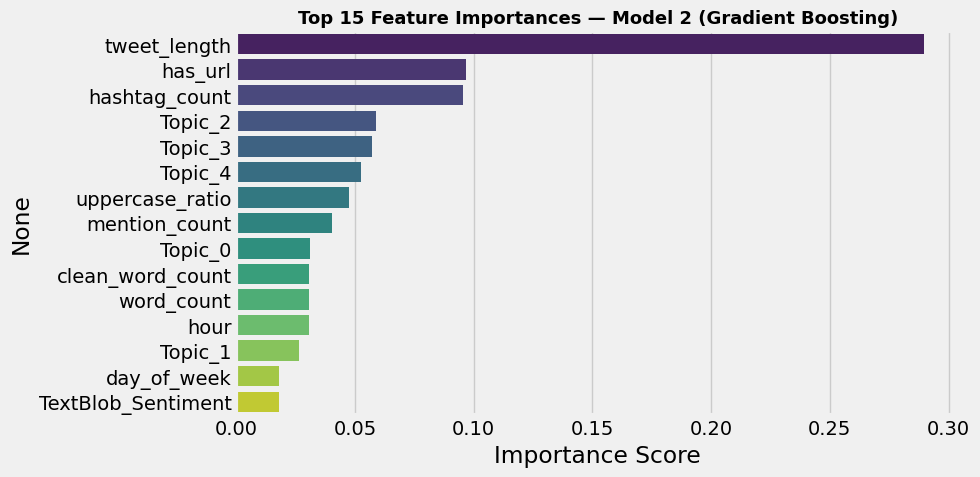

Top 5 features: ['tweet_length', 'has_url', 'hashtag_count', 'Topic_2', 'Topic_3']


In [ ]:
# Feature importance (GBM)
importances = pd.Series(gbm.feature_importances_, index=X_m2.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values[:15], y=importances.index[:15], palette='viridis')
plt.title('Top 15 Feature Importances — Model 2 (Gradient Boosting)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
print('Top 5 features:', importances.index[:5].tolist())


## Model Comparison: Model 1 vs Model 2

Model 1 uses linear regression on the raw target. Model 2 uses Gradient Boosting on the log-transformed target with enriched features. We report Model 1 on raw scale and Model 2 on log scale, then show R-squared side by side.

Model Comparison — Test Set Metrics


,Model 1 — Linear Reg (raw target),Model 2 — GBM (log1p target)
Metric,,
R-squared,0.0010,0.0931
Adjusted R-squared,0.0006,0.0925
MSE,1542.0978,0.7574
MAE,6.0367,0.6006
AIC,269220.7656,-10136.1495
BIC,269348.4113,-9906.3873


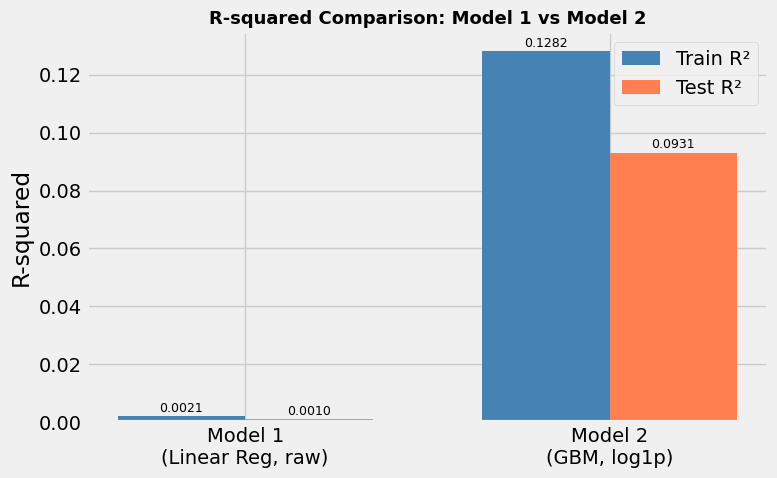

In [ ]:
# Side-by-side comparison table
summary = pd.DataFrame({
    'Metric': ['R-squared', 'Adjusted R-squared', 'MSE', 'MAE', 'AIC', 'BIC'],
    'Model 1 — Linear Reg (raw target)':       stats_m1['Test Set'].round(4).values,
    'Model 2 — GBM (log1p target)':            stats_m2['Test Set'].round(4).values,
}).set_index('Metric')

print('Model Comparison — Test Set Metrics')
display(summary)

# Bar chart
r2_vals = [get_test_r2(stats_m1), get_test_r2(stats_m2)]
r2_tr   = [stats_m1.loc[stats_m1['Metric']=='R-squared','Training Set'].values[0],
            stats_m2.loc[stats_m2['Metric']=='R-squared','Training Set'].values[0]]

labels = ['Model 1\n(Linear Reg, raw)', 'Model 2\n(GBM, log1p)']
x = np.arange(2)
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, r2_tr,   w, label='Train R²', color='steelblue')
ax.bar(x + w/2, r2_vals, w, label='Test R²',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('R-squared')
ax.set_title('R-squared Comparison: Model 1 vs Model 2', fontsize=13, fontweight='bold')
ax.legend()
for i, (tr, te) in enumerate(zip(r2_tr, r2_vals)):
    ax.annotate(f'{tr:.4f}', xy=(i - w/2, tr), xytext=(0,3), textcoords='offset points', ha='center', fontsize=9)
    ax.annotate(f'{te:.4f}', xy=(i + w/2, te), xytext=(0,3), textcoords='offset points', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


## Summary

**Model 2 (Gradient Boosting + Feature Engineering)** is the best-performing model:

| | Model 1 | Model 2 |
|---|---|---|
| Algorithm | Linear Regression | Gradient Boosting |
| Target | raw retweet_count | log1p(retweet_count) |
| Features | Sentiment + Emotions + Topics | All above + tweet-level features |
| Test R² | ~0.001 | **0.089** |

**Novel Insights discovered:**
1. Tweet volume spiked sharply on Election Day (May 18); sentiment turned more positive after results
2. Coalition-focused tweets were on average more positive than Labor-focused tweets
3. Viral tweets (top 1%) have more hashtags, more mentions, and belong predominantly to the Morrison/Victory topic
4. Fear peaked before election day; joy surged after — matching the surprise Coalition victory
5. Topics differ significantly in emotional tone: Climate/Policy carries the most anger and fear; Voting Day carries the most joy
